In [1]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset
df = pd.read_csv("amazonreviews.tsv", sep='\t', encoding='latin-1')

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.dropna(inplace=True)

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Text cleaning function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

# Apply preprocessing
df['clean_review'] = df['review'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to C:\Users\SUGANYA
[nltk_data]     P\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\SUGANYA
[nltk_data]     P\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


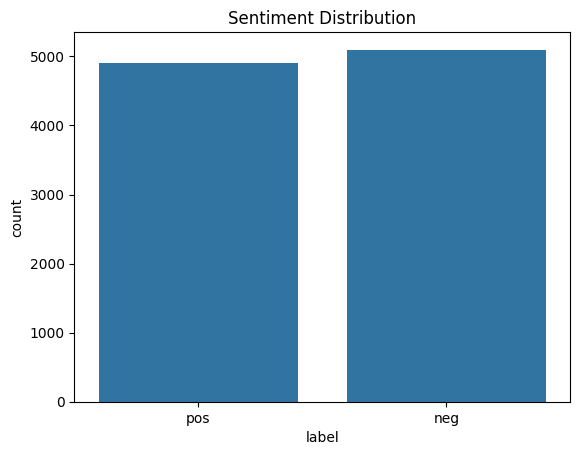

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Sentiment Distribution")
plt.show()

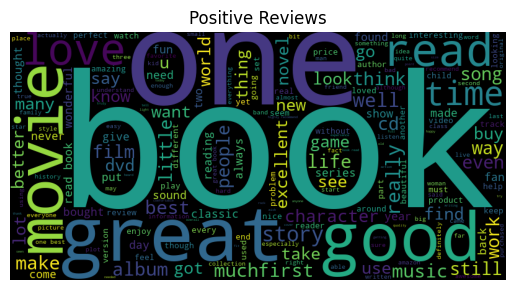

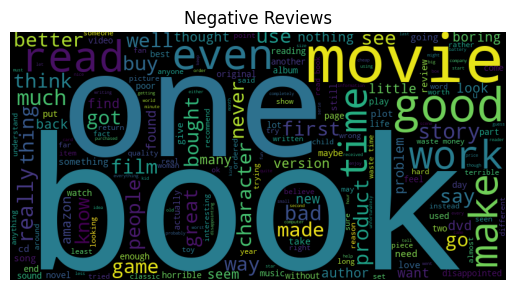

In [3]:
from wordcloud import WordCloud

# Positive reviews
pos_text = " ".join(df[df['label']=='pos']['clean_review'])
neg_text = " ".join(df[df['label']=='neg']['clean_review'])

wordcloud_pos = WordCloud(width=800, height=400).generate(pos_text)
wordcloud_neg = WordCloud(width=800, height=400).generate(neg_text)

plt.imshow(wordcloud_pos)
plt.axis('off')
plt.title("Positive Reviews")
plt.show()

plt.imshow(wordcloud_neg)
plt.axis('off')
plt.title("Negative Reviews")
plt.show()

In [4]:
#Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review']).toarray()
y = df['label'].map({'pos':1, 'neg':0})

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [7]:
#SVM
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

In [9]:
# Advanced Feature Engineering using Word2Vec

from gensim.models import Word2Vec

# Tokenize reviews
tokenized_reviews = [text.split() for text in df['clean_review']]

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

# Function to create average Word2Vec vectors
def get_avg_word2vec(tokens, model, vector_size):
    feature_vec = np.zeros((vector_size,), dtype="float32")
    count = 0

    for word in tokens:
        if word in model.wv:
            feature_vec += model.wv[word]
            count += 1

    if count != 0:
        feature_vec /= count

    return feature_vec

# Create feature vectors
X_w2v = np.array([
    get_avg_word2vec(text.split(), w2v_model, 100)
    for text in df['clean_review']
])

# Labels
y = df['label'].map({'pos':1, 'neg':0})

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Accuracy: 0.725

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.76      0.74      1037
           1       0.72      0.69      0.71       963

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.72      0.72      0.72      2000



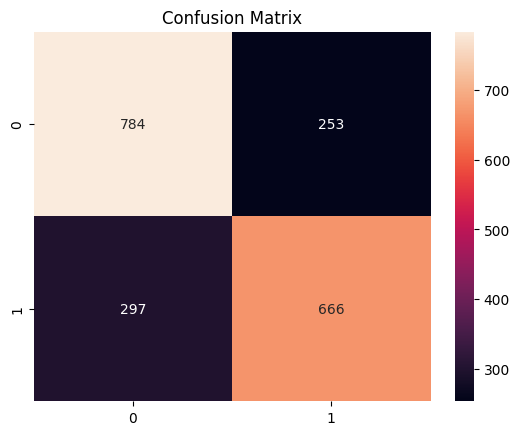

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d')

plt.title("Confusion Matrix")
plt.show()